# Simulation Diagnostics

`scene.trace()` returns a `SimulationResult` that contains both the per-detector
results and a complete flux budget for the simulation. Understanding this object
is essential for verifying that a simulation is physically correct.

**Flux accounting.** Every watt launched by a source must end up somewhere:

```
total_flux_in = total_flux_detected + total_flux_absorbed + total_flux_bulk_absorbed
              + total_flux_escaped  + total_flux_lost
```

`total_flux_absorbed` is surface absorption (an `AbsorbingComponent` a ray hit
directly); `total_flux_bulk_absorbed` is Beer-Lambert absorption accumulated
while a ray travels through a lossy glass (nonzero extinction coefficient `k`)
-- automatic whenever a lens/doublet uses such a material, no configuration
needed. The demo lens below uses N-BK7, whose `k` at 0.55 µm is small but not
exactly zero, so `total_flux_bulk_absorbed` reads a small (<0.1%) but genuine
value throughout this notebook rather than a rounding artefact.

The `flux_conservation_error` field tells you how well the simulation preserves
energy. Values below 1e-4 are typical. The sections below build these checks up
by hand; the "Self-diagnosing results" section further down runs the same
checks automatically on every trace.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from optiland.coordinate_system import CoordinateSystem
from optiland.nonsequential import (
    NSQScene, Spectrum,
    CollimatedSourceConfig, PointSourceConfig,
    IrradianceDetectorConfig,
    LensConfig,
)

spec = Spectrum.monochromatic(0.55)

## 1. Full SimulationResult Structure

In [2]:
scene = NSQScene()
scene.add_source(
    'S', CoordinateSystem(z=-80),
    CollimatedSourceConfig(spectrum=spec, total_flux=1.0, aperture_radius=10.0),
)
scene.add_lens(
    'L', CoordinateSystem(z=0),
    LensConfig(r1=50, r2=-50, thickness=5, material='N-BK7', front_aperture_radius=12.5),
)
# f = 49.1 mm and a 47.4 mm back focal distance put the focus at z = 52.4 mm.
scene.add_detector(
    'D', CoordinateSystem(z=52.4),
    IrradianceDetectorConfig(width=6, height=6, num_pixels_x=128, num_pixels_y=128),
)

result = scene.trace(num_rays=50_000, seed=42)

# Print every field of SimulationResult
print("=== SimulationResult ===")
print(f"  trace_time_sec         : {result.trace_time_sec:.3f} s")
print(f"  num_rays_total         : {result.num_rays_total:,}")
print(f"  num_rays_absorbed      : {result.num_rays_absorbed:,}")
print(f"  num_rays_escaped       : {result.num_rays_escaped:,}")
print(f"  num_rays_flux_killed   : {result.num_rays_flux_killed:,}")
print(f"  num_rays_depth_killed  : {result.num_rays_depth_killed:,}")
print()
print(f"  total_flux_in          : {result.total_flux_in:.6f} W")
print(f"  total_flux_detected    : {result.total_flux_detected:.6f} W")
print(f"  total_flux_absorbed    : {result.total_flux_absorbed:.6f} W")
print(f"  total_flux_bulk_absorbed: {result.total_flux_bulk_absorbed:.6f} W")
print(f"  total_flux_escaped     : {result.total_flux_escaped:.6f} W")
print(f"  total_flux_lost        : {result.total_flux_lost:.6f} W")
print(f"  flux_conservation_error: {result.flux_conservation_error:.2e}")
print()
print("  Detectors              :", list(result.detectors.keys()))

=== SimulationResult ===
  trace_time_sec         : 0.217 s
  num_rays_total         : 50,000
  num_rays_absorbed      : 0
  num_rays_escaped       : 4,145
  num_rays_flux_killed   : 0
  num_rays_depth_killed  : 0

  total_flux_in          : 1.000000 W
  total_flux_detected    : 0.916491 W
  total_flux_absorbed    : 0.000000 W
  total_flux_bulk_absorbed: 0.000672 W
  total_flux_escaped     : 0.082837 W
  total_flux_lost        : 0.000000 W
  flux_conservation_error: 4.16e-17

  Detectors              : ['D']


## 2. Flux Budget Pie Chart

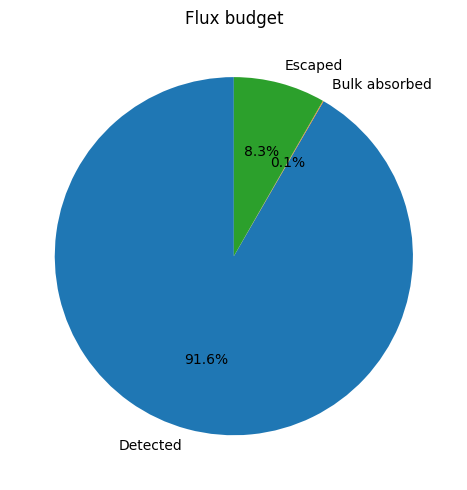

In [3]:
labels = ['Detected', 'Absorbed', 'Bulk absorbed', 'Escaped', 'Lost']
values = [
    result.total_flux_detected,
    result.total_flux_absorbed,
    result.total_flux_bulk_absorbed,
    result.total_flux_escaped,
    result.total_flux_lost,
]
# Filter out zero categories
labels_filt = [l for l, v in zip(labels, values) if v > 1e-9]
values_filt = [v for v in values if v > 1e-9]

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(values_filt, labels=labels_filt, autopct='%1.1f%%', startangle=90)
ax.set_title('Flux budget')
plt.tight_layout()
plt.show()
plt.close(fig)

## 3. Effect of Ray Count on Accuracy

More rays give a smoother irradiance map and a more reliable flux estimate.
Here we trace the same scene with different ray counts and compare peak irradiance:

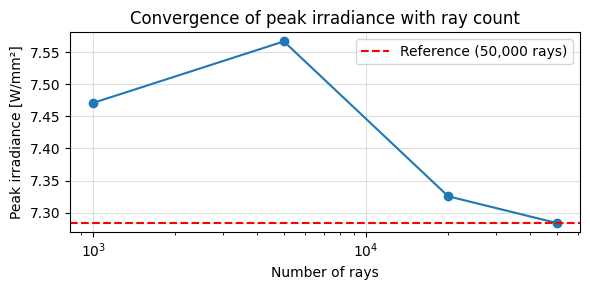

In [4]:
def build_scene():
    s = NSQScene()
    s.add_source('S', CoordinateSystem(z=-80),
                 CollimatedSourceConfig(spectrum=spec, total_flux=1.0, aperture_radius=10.0))
    s.add_lens('L', CoordinateSystem(z=0),
               LensConfig(r1=50, r2=-50, thickness=5, material='N-BK7',
                          front_aperture_radius=12.5))
    s.add_detector('D', CoordinateSystem(z=52.4),
                   IrradianceDetectorConfig(width=6, height=6,
                                            num_pixels_x=64, num_pixels_y=64))
    return s

ray_counts = [1_000, 5_000, 20_000, 50_000]
peaks = []
for n in ray_counts:
    r = build_scene().trace(num_rays=n, seed=42)
    peaks.append(r.detectors['D'].irradiance.max())

fig, ax = plt.subplots(figsize=(6, 3))
ax.semilogx(ray_counts, peaks, 'o-')
ax.axhline(peaks[-1], color='r', linestyle='--', label=f'Reference ({ray_counts[-1]:,} rays)')
ax.set_xlabel('Number of rays')
ax.set_ylabel('Peak irradiance [W/mm²]')
ax.set_title('Convergence of peak irradiance with ray count')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
plt.close(fig)

## 4. Controlling Ray Termination

Two parameters decide when a ray stops being traced:

- **`max_depth`** (default 16): a ray is killed outright after this many
  surface hits. Every interaction counts, so a ray passing through a singlet
  already uses two (front face, back face) before it reaches a detector.
  This is the one loss mechanism that is an *inherent, reported bias* --
  raise it if deep paths (internal reflections, ghosts) matter to the
  result; lower it to speed up runs where they do not.

- **`min_flux_fraction`** (default 1e-6): below this fraction of a ray's
  initial flux, the ray is **Russian-rouletted**, not deterministically
  killed -- with probability *p* it is terminated, and survivors have their
  flux boosted by `1/(1-p)` to compensate. This is unbiased in expectation
  (unlike a hard cutoff, which would systematically lose flux), so raising
  it trades variance for speed rather than introducing bias outright.

Flux removed by either mechanism is reported as `total_flux_lost`, and it is
part of the ledger, so `flux_conservation_error` stays near zero even when
rays are being killed. `SimulationResult.diagnostics` (see below) separates
the two into `depth_truncated_flux_fraction` and `rr_killed_flux_fraction`
so a large `total_flux_lost` can be traced back to whichever mechanism
caused it.

In [5]:
# max_depth must be large enough for light to reach the detector at all:
# a singlet needs two hits (front and back face) before the ray gets there.
for max_b in [1, 2, 5, 20]:
    r = build_scene().trace(num_rays=30_000, seed=42,
                            max_depth=max_b, min_flux_fraction=1e-8)
    irr = r.detectors['D']
    print(f"max_depth={max_b:>3}: detected {irr.total_flux:.5f} W  "
          f"({irr.num_rays_hit:>6,} rays)  "
          f"lost={r.total_flux_lost:.5f} W  "
          f"depth_killed={r.num_rays_depth_killed:>6,}  "
          f"err={r.flux_conservation_error:.1e}")


max_depth=  1: detected 0.00000 W  (     0 rays)  lost=1.00000 W  depth_killed=30,000  err=2.2e-16
max_depth=  2: detected 0.00000 W  (     0 rays)  lost=0.95780 W  depth_killed=28,753  err=0.0e+00


max_depth=  5: detected 0.91656 W  (27,515 rays)  lost=0.00093 W  depth_killed=    28  err=2.8e-16
max_depth= 20: detected 0.91656 W  (27,515 rays)  lost=0.00000 W  depth_killed=     0  err=2.8e-16


## 5. Reproducibility with `seed`

Setting `seed` fixes the NumPy random number generator. Two traces with the
same `seed` produce identical results. Omitting `seed` gives a different result
each time (useful for estimating Monte Carlo variance).

In [6]:
r1 = build_scene().trace(num_rays=10_000, seed=7)
r2 = build_scene().trace(num_rays=10_000, seed=7)  # same seed
r3 = build_scene().trace(num_rays=10_000, seed=99) # different seed

f1 = r1.detectors['D'].total_flux
f2 = r2.detectors['D'].total_flux
f3 = r3.detectors['D'].total_flux

print(f"Same seed (7, 7)   : flux1 = {f1:.6f} W,  flux2 = {f2:.6f} W  → identical: {np.isclose(f1, f2)}")
print(f"Diff seed (7, 99)  : flux1 = {f1:.6f} W,  flux3 = {f3:.6f} W  → same: {np.isclose(f1, f3)}")

Same seed (7, 7)   : flux1 = 0.919287 W,  flux2 = 0.919287 W  → identical: True
Diff seed (7, 99)  : flux1 = 0.919287 W,  flux3 = 0.913693 W  → same: False


## 6. Batch Size

`batch_size` sets how many rays are traced in one chunk. It is a **performance
control, not a physical parameter**: the result must not depend on it, beyond
Monte Carlo noise from consuming the random stream differently.

The default of 16,384 rays per batch is tuned so the working set stays in CPU
cache, which is where the trace loop is fastest. Raising it costs speed without
saving memory, and raising it beyond the ray count has no effect at all.
Notebook 10 measures the speed curve directly.


In [7]:
fluxes = {}
for bs in (1_000, 5_000, 20_000, 1_000_000):
    r = build_scene().trace(num_rays=20_000, seed=42, batch_size=bs)
    fluxes[bs] = r.detectors['D'].total_flux
    print(f"batch_size={bs:>9,}: flux = {fluxes[bs]:.6f} W  "
          f"(conservation error {r.flux_conservation_error:.1e})")

spread = max(fluxes.values()) - min(fluxes.values())
print(f"\nSpread across batch sizes: {spread:.2e} W "
      f"({spread / np.mean(list(fluxes.values())) * 100:.2f}% - Monte Carlo noise only)")


batch_size=    1,000: flux = 0.915442 W  (conservation error 2.8e-16)
batch_size=    5,000: flux = 0.915442 W  (conservation error 2.6e-16)


batch_size=   20,000: flux = 0.915442 W  (conservation error 4.9e-16)
batch_size=1,000,000: flux = 0.915442 W  (conservation error 4.9e-16)

Spread across batch sizes: 2.22e-16 W (0.00% - Monte Carlo noise only)


## 7. Self-Diagnosing Results: `result.report()`

Sections 2-6 above hand-built several checks: does the flux ledger balance,
how much is `max_depth`/`min_flux_fraction` losing, does the result depend
on `batch_size`. `SimulationResult.diagnostics` (a `Diagnostics` object)
computes the same kind of checks automatically, at negligible extra cost
(a few running counters plus one pass over the detectors), and turns them
into an explicit, threshold-based warning list rather than numbers you have
to know to go looking for:

- **`depth_truncated_flux_fraction`** -- fraction of launched flux killed by
  the hard `max_depth` cutoff. The *only* loss mechanism here that is an
  inherent, reported *bias*; a nonzero value is a direct signal to raise
  `max_depth` if those deep paths matter.
- **`rr_killed_flux_fraction`** -- fraction killed by Russian roulette
  (section 4). Unbiased in expectation, so a nonzero value means the
  per-trace estimator is noisy, not necessarily wrong.
- **`flux_conservation_error`** -- the same field printed in section 1,
  copied here for convenience.
- **`unreached_geometry`** -- names of scene components no ray ever hit over
  the whole trace: usually a misplaced or mis-oriented surface, occasionally
  a deliberately unused spare aperture.
- **`detectors`** -- a `DetectorDiagnostic` per detector: `mean_hits_per_pixel`,
  `undersampled` (shot noise dominates the map below ~10 hits/pixel), and
  `rays_needed_for_5pct` (an estimate of the ray count that would bring an
  undersampled detector to ~5% relative Poisson error).
- **`medium_stack_underflows`**, **`split_budget_saturated`** -- always 0 /
  `False` for scenes like the ones in this notebook; reserved for a future
  runtime medium-nesting stack and for scenes using bounded ghost-path
  splitting, respectively.

`result.report()` renders all of this as text with a trailing warning
section; `repr(result)` shows just a warning count, so a problem is visible
even from a bare REPL echo. Re-running the section 1 scene below is a
realistic example, not a contrived one -- and it already has something to
say.

In [8]:
# Reuse the well-behaved scene from section 1.
print(result.report())
print()
print(repr(result))

NSQ trace diagnostics:
  depth_truncated_flux_fraction: 0.0000%
  rr_killed_flux_fraction:       0.0000%
  flux_conservation_error:       0.0000%
  unreached_geometry:            ['L.edge']
  medium_stack_underflows:       0
  split_budget_saturated:        False
  detectors:
    D: 45855 hits, 2.80 mean hits/pixel [undersampled]
Warnings:
  - 1 component(s) were never hit by any ray: L.edge. Check placement/orientation, or ignore if intentionally unused.
  - Detector 'D' is undersampled: 2.8 mean hits/pixel (< 10), shot noise dominates the map; ~7,146,003 rays would bring it to ~5% relative error.

SimulationResult(num_rays_total=50000, detectors=['D'], total_flux_in=1, total_flux_detected=0.916491, flux_conservation_error=4.163e-17, 2 diagnostic warning(s))


Two warnings, and both are informative rather than alarming:

- `L.edge` (the lens's cylindrical barrel) is unreached -- expected here,
  since a 10 mm-radius collimated beam never gets near the 12.5 mm-radius
  barrel of a lens it enters straight down the axis. This is the "ignore if
  intentionally unused" case the docstring calls out.
- Detector `D` is undersampled: 128x128 = 16,384 pixels but only ~46,000 hits,
  so `mean_hits_per_pixel` is well under the 10-hit shot-noise floor. This
  *is* actionable -- it is the same convergence question section 3 asked by
  hand, now with a concrete ray-count estimate (`rays_needed_for_5pct`)
  attached instead of a squint-and-guess plot.

### Tripping the warnings on purpose

To see a more serious case, build a scene with two deliberate problems: an
order of magnitude too few rays for the detector (severe undersampling), and
a spare mirror parked well outside the 10 mm-radius collimated beam so no
ray can ever reach it (unreached geometry that is *not* an innocuous barrel).

In [9]:
from optiland.nonsequential import MirrorConfig


def build_scene_with_spare_mirror():
    s = build_scene()
    # Well clear of the 10 mm-radius beam and the 12.5 mm-aperture lens: no
    # ray can reach it, so diagnostics.unreached_geometry should flag it.
    s.add_mirror(
        'spare_M', CoordinateSystem(x=60.0, z=0),
        MirrorConfig(radius=-100.0, aperture_radius=10.0, reflectance=0.9),
    )
    return s


# 300 rays into a 64x64 = 4,096-pixel detector -- far below the ~10
# hits/pixel needed before shot noise stops dominating the map.
result_noisy = build_scene_with_spare_mirror().trace(num_rays=300, seed=42)
print(result_noisy.report())

NSQ trace diagnostics:
  depth_truncated_flux_fraction: 0.0000%
  rr_killed_flux_fraction:       0.0000%
  flux_conservation_error:       0.0000%
  unreached_geometry:            ['L.edge', 'spare_M.surface']
  medium_stack_underflows:       0
  split_budget_saturated:        False
  detectors:
    D: 278 hits, 0.07 mean hits/pixel [undersampled]
Warnings:
  - 2 component(s) were never hit by any ray: L.edge, spare_M.surface. Check placement/orientation, or ignore if intentionally unused.
  - Detector 'D' is undersampled: 0.1 mean hits/pixel (< 10), shot noise dominates the map; ~1,768,057 rays would bring it to ~5% relative error.


Depth truncation is easy to trigger too: rerun the `max_depth=1` case from
section 4, where every ray was killed before reaching the lens's back face.
`diagnostics.depth_truncated_flux_fraction` should read essentially 100%,
and the warning list should say so in plain language.

In [10]:
result_truncated = build_scene().trace(num_rays=30_000, seed=42, max_depth=1)

print(f"depth_truncated_flux_fraction: "
      f"{result_truncated.diagnostics.depth_truncated_flux_fraction:.2%}")
print()
for w in result_truncated.diagnostics.warnings():
    print(f"- {w}")

depth_truncated_flux_fraction: 100.00%

- 100.00% of launched flux was truncated by max_depth -- results are incomplete for paths deeper than max_depth; raise it if those paths matter.
- 2 component(s) were never hit by any ray: L.back, L.edge. Check placement/orientation, or ignore if intentionally unused.
- Detector 'D' is undersampled: 0.0 mean hits/pixel (< 10), shot noise dominates the map.


## 8. Putting It Together

A compact visual summary of the three checks worth running on any new scene:
does the flux ledger balance, has the result converged in ray count, and is
the beam where you expect it? `result.report()` above answers the first two
numerically already; this is the same information laid out for a quick
visual scan.

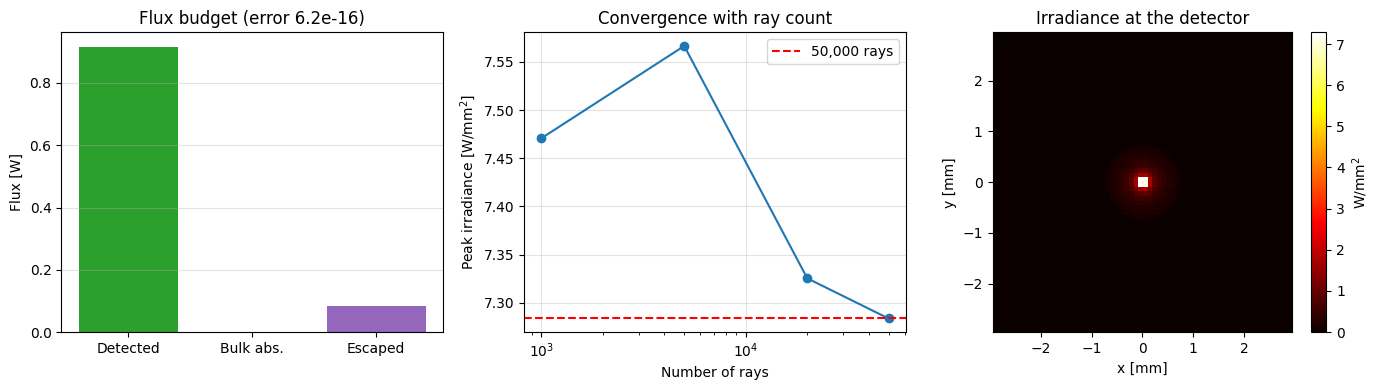

In [11]:
result_final = build_scene().trace(num_rays=50_000, seed=42)
irr_final = result_final.detectors['D']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- flux budget -----------------------------------------------------------
channels = {
    'Detected': result_final.total_flux_detected,
    'Absorbed': result_final.total_flux_absorbed,
    'Bulk abs.': result_final.total_flux_bulk_absorbed,
    'Escaped': result_final.total_flux_escaped,
    'Lost': result_final.total_flux_lost,
}
present = {k: v for k, v in channels.items() if v > 1e-9}
ax = axes[0]
ax.bar(present.keys(), present.values(), color=['tab:green', 'tab:orange',
                                                'tab:purple', 'tab:blue',
                                                'tab:red'][:len(present)])
ax.set_ylabel('Flux [W]')
ax.set_title(f'Flux budget (error {result_final.flux_conservation_error:.1e})')
ax.grid(True, axis='y', alpha=0.35)

# --- convergence -----------------------------------------------------------
ax = axes[1]
ax.semilogx(ray_counts, peaks, 'o-')
ax.axhline(peaks[-1], color='r', ls='--', label=f'{ray_counts[-1]:,} rays')
ax.set_xlabel('Number of rays')
ax.set_ylabel('Peak irradiance [W/mm$^2$]')
ax.set_title('Convergence with ray count')
ax.legend()
ax.grid(True, alpha=0.35)

# --- the beam itself -------------------------------------------------------
ax = axes[2]
im = ax.imshow(irr_final.irradiance, origin='lower', cmap='hot',
               extent=[irr_final.x_coords[0], irr_final.x_coords[-1],
                       irr_final.y_coords[0], irr_final.y_coords[-1]])
plt.colorbar(im, ax=ax, label='W/mm$^2$')
ax.set_xlabel('x [mm]')
ax.set_ylabel('y [mm]')
ax.set_title('Irradiance at the detector')

plt.tight_layout()
plt.show()

## Summary

- `SimulationResult` tracks every flux channel: detected, absorbed, bulk-absorbed,
  escaped, lost
- `flux_conservation_error` validates the ledger and should sit near machine precision
- More rays lower the Monte Carlo noise; watch a key metric converge before trusting it
- `max_depth` must exceed the number of surfaces a ray has to cross and is the one
  *biased* loss mechanism; `min_flux_fraction` sets an unbiased Russian-roulette
  threshold, not a hard cutoff
- Use `seed` for reproducible runs; omit it to sample Monte Carlo variance
- `batch_size` affects speed only and must not change the answer
- `result.diagnostics` / `result.report()` automate exactly these checks --
  depth truncation, roulette loss, flux conservation, unreached geometry, and
  per-detector undersampling -- with a threshold-based warning list. Read the
  report before trusting a trace's numbers, especially for scenes more complex
  than this notebook's single lens